In [10]:
import pandas as pd
import json
import os

# import all data
voc_keys = ["ethylbenzene", "formaldehyde", "isobutyraldehyde"]

voc_data = {}

for voc in voc_keys:
    df = pd.read_csv(f"{voc}_clean.csv")
    
    with open(f"{voc}_meta.json", "r") as f:
        meta = json.load(f)
    
    voc_data[voc] = {
        "df": df,
        "meta": meta
    }

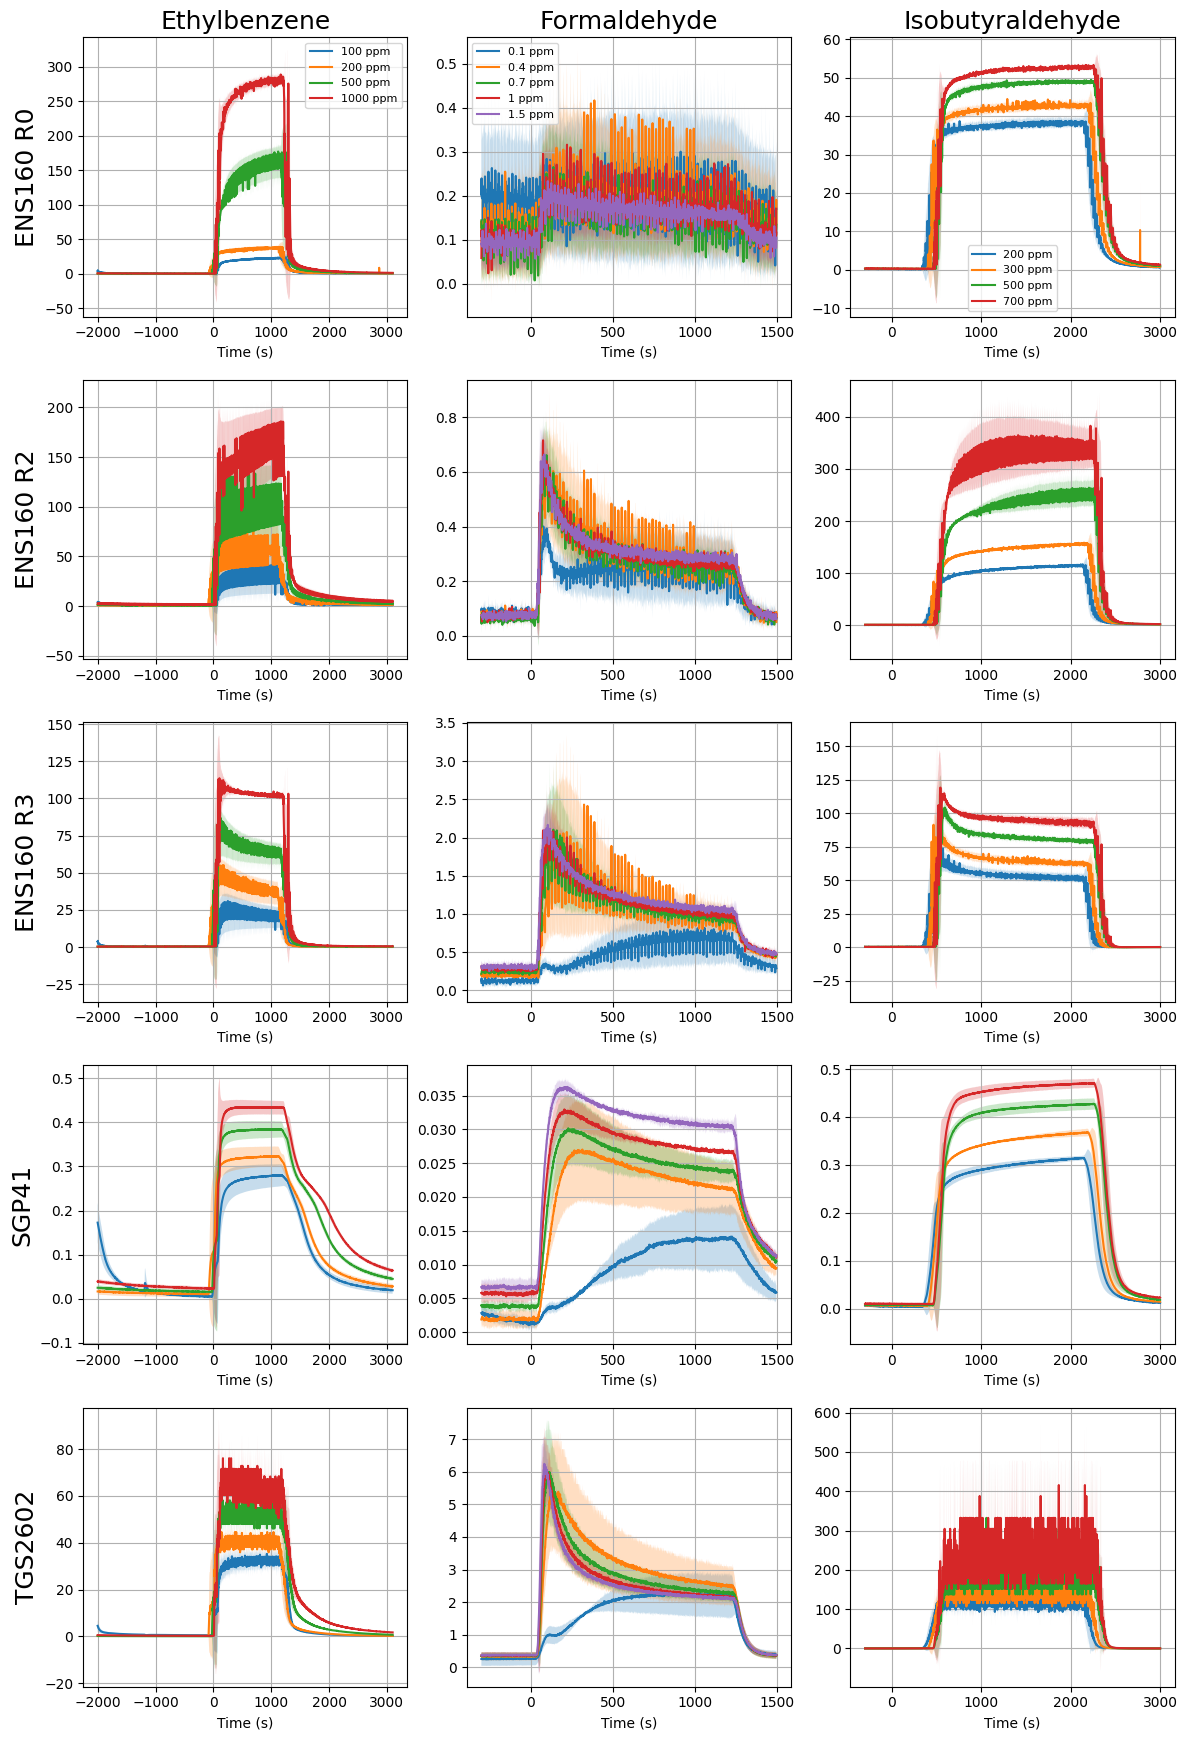

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# order for plotting
voc_order = ["ethylbenzene", "formaldehyde", "isobutyraldehyde"]

# get sensor names from first VOC
sample_df = voc_data[voc_order[0]]["df"]
cols = list(sample_df.columns)
time_col = cols[0]
sensor_cols = cols[1:]
sensor_names = ["ENS160 R0", "ENS160 R2", "ENS160 R3", "SGP41", "TGS2602"]

nrows = len(sensor_names)
ncols = len(voc_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3.5*nrows),
)

# make axes always 2D
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)
if ncols == 1:
    axes = np.expand_dims(axes, axis=1)

for c, voc in enumerate(voc_order):
    df = voc_data[voc]["df"]
    meta = voc_data[voc]["meta"]

    onsets = meta["onsets"]
    labels = meta["labels"]
    pre = meta["pre"]
    post = meta["post"]
    dt = meta.get("dt", 1)

    cols = list(df.columns)
    time_col = cols[0]
    sensor_cols = cols[1:]
    n_sensors = len(sensor_cols) // 2

    for r in range(n_sensors):
        ax = axes[r, c]

        mean_col = sensor_cols[2*r]
        std_col  = sensor_cols[2*r + 1]

        avg = df[mean_col].astype(float).to_numpy()
        std = df[std_col].astype(float).to_numpy()

        t = np.arange(-pre, post) * dt

        for j, onset in enumerate(onsets):
            start = onset - pre
            end = onset + post

            if start < 0 or end > len(avg):
                continue

            a = avg[start:end]
            s = std[start:end]

            n = min(len(t), len(a), len(s))

            ax.plot(t[:n], a[:n], label=labels[j])
            ax.fill_between(
                t[:n],
                (a - s)[:n],
                (a + s)[:n],
                alpha=0.25
            )

        if r == 0:
            ax.set_title(voc.replace("_", " ").title(), fontsize=18)
        if c == 0:
            ax.set_ylabel(sensor_names[r], fontsize=18)
        ax.set_xlabel("Time (s)")

        ax.grid(True)

        # only show legend on top row to reduce clutter
        if r == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

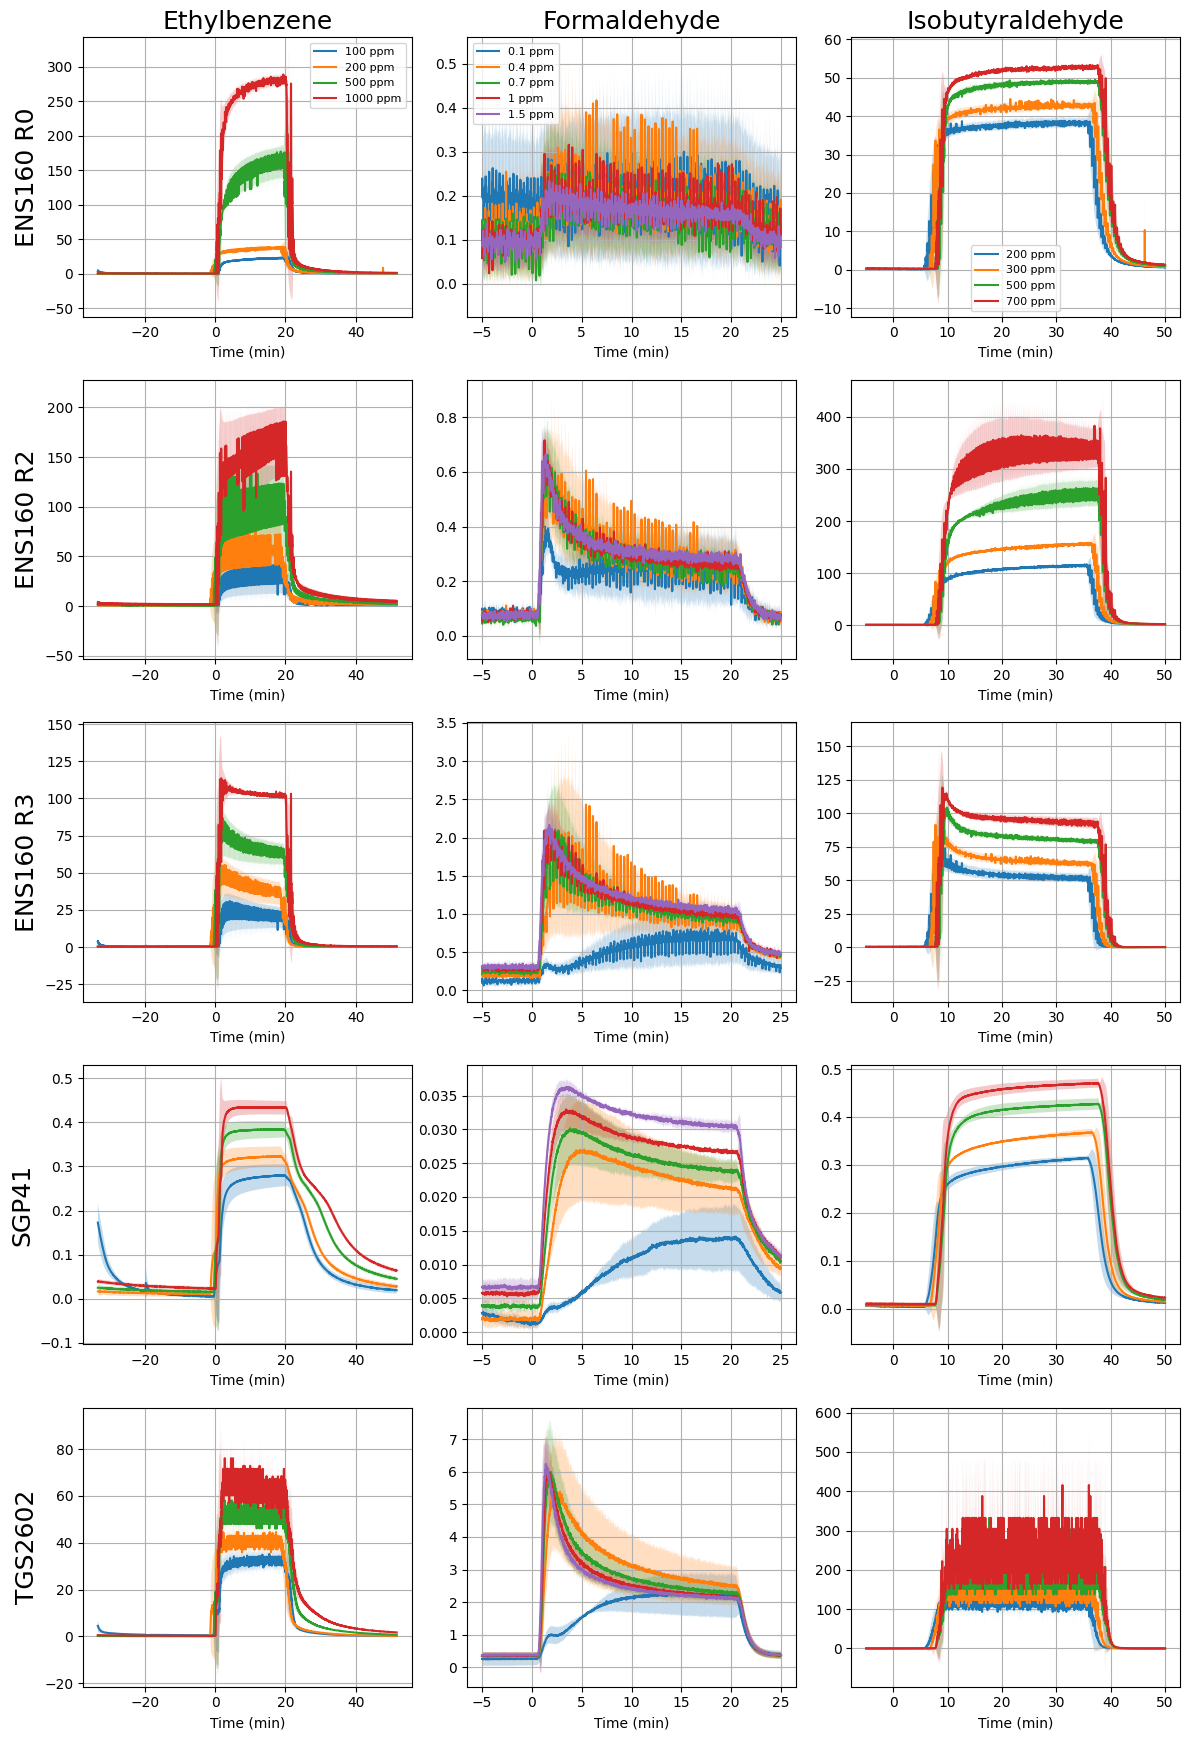

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# order for plotting
voc_order = ["ethylbenzene", "formaldehyde", "isobutyraldehyde"]

# get sensor names from first VOC
sample_df = voc_data[voc_order[0]]["df"]
cols = list(sample_df.columns)
time_col = cols[0]
sensor_cols = cols[1:]
sensor_names = ["ENS160 R0", "ENS160 R2", "ENS160 R3", "SGP41", "TGS2602"]

nrows = len(sensor_names)
ncols = len(voc_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3.5*nrows),
)

# make axes always 2D
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)
if ncols == 1:
    axes = np.expand_dims(axes, axis=1)

for c, voc in enumerate(voc_order):
    df = voc_data[voc]["df"]
    meta = voc_data[voc]["meta"]

    onsets = meta["onsets"]
    labels = meta["labels"]
    pre = meta["pre"]
    post = meta["post"]
    dt = meta.get("dt", 1)

    cols = list(df.columns)
    time_col = cols[0]
    sensor_cols = cols[1:]
    n_sensors = len(sensor_cols) // 2

    for r in range(n_sensors):
        ax = axes[r, c]

        mean_col = sensor_cols[2*r]
        std_col  = sensor_cols[2*r + 1]

        avg = df[mean_col].astype(float).to_numpy()
        std = df[std_col].astype(float).to_numpy()

        t = (np.arange(-pre, post) * dt) / 60

        for j, onset in enumerate(onsets):
            start = onset - pre
            end = onset + post

            if start < 0 or end > len(avg):
                continue

            a = avg[start:end]
            s = std[start:end]

            n = min(len(t), len(a), len(s))

            ax.plot(t[:n], a[:n], label=labels[j])
            ax.fill_between(
                t[:n],
                (a - s)[:n],
                (a + s)[:n],
                alpha=0.25
            )

        if r == 0:
            ax.set_title(voc.replace("_", " ").title(), fontsize=18)
        if c == 0:
            ax.set_ylabel(sensor_names[r], fontsize=18)
        ax.set_xlabel("Time (min)")

        ax.grid(True)

        # only show legend on top row to reduce clutter
        if r == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()